An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


0.00011473894119262695
0:05:52.161635


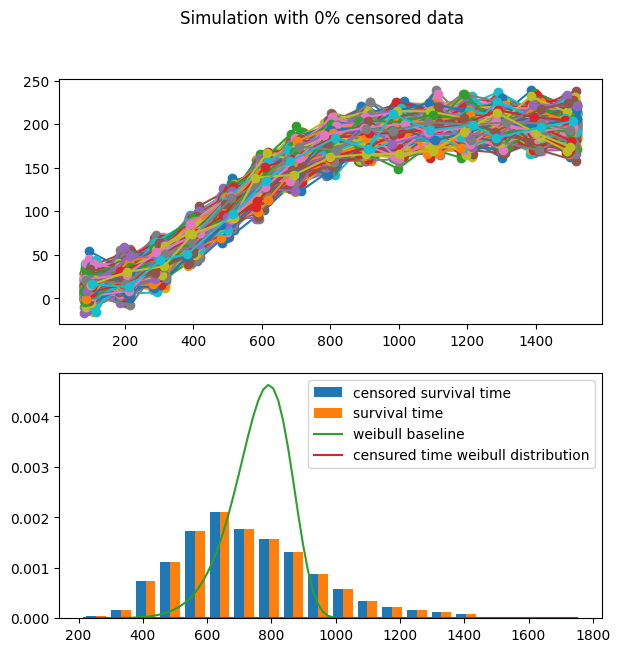

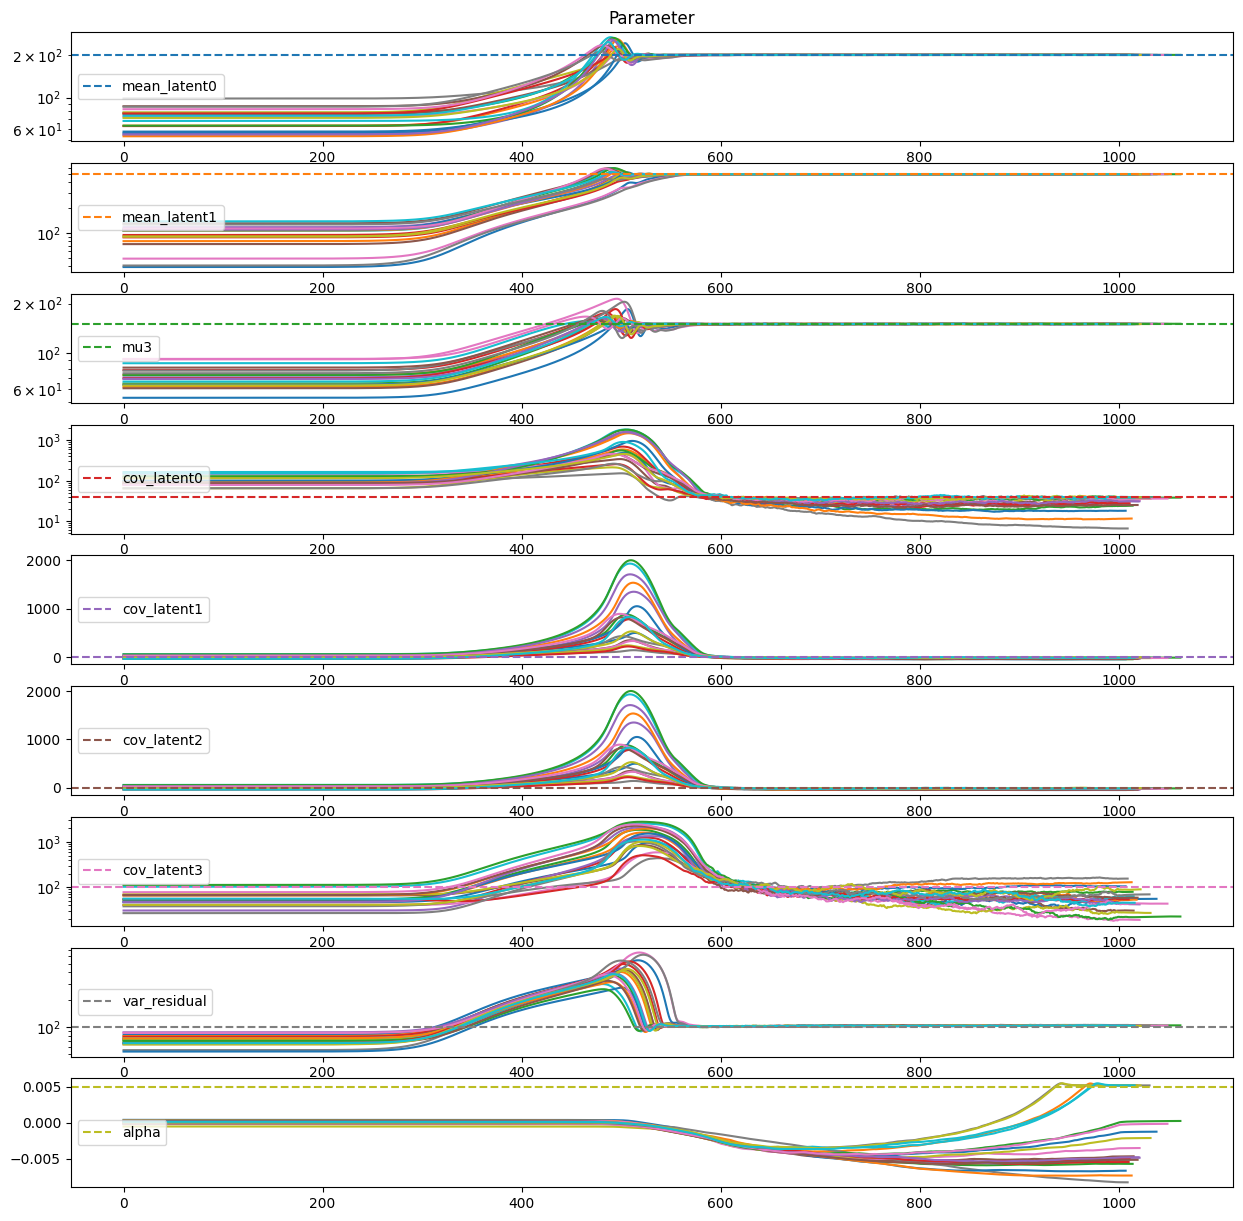

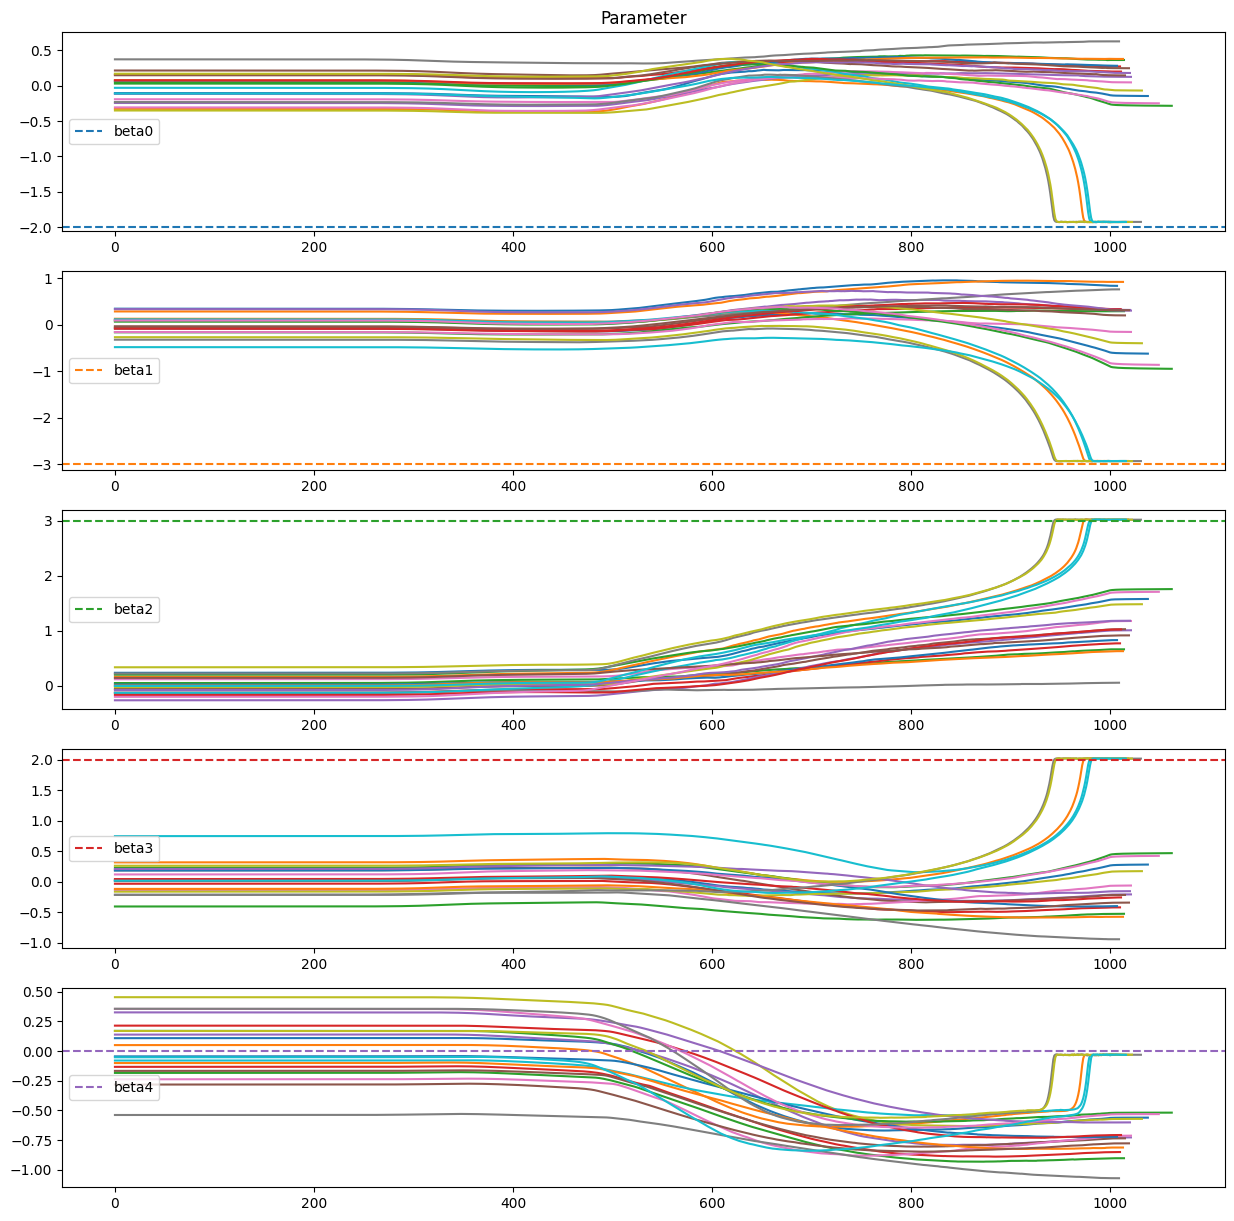

In [1]:
"""
Module that define functions to perform a simple estimation.

Create by antoine.caillebotte@inrae.fr"""

# pylint: disable=C0116
import jax.random as jrd
import jax.numpy as jnp

# import jax.numpy as jnp

from sdg4varselect import sdgplt
from sdg4varselect.outputs import MultiRunRes

from sdg4varselect.algo import SGD_FIM, SPGD_FIM, get_GDFIM_settings


algo_settings = get_GDFIM_settings(preheating=600, heating=1000, learning_rate=1e-6)


def one_estim(prngkey, model, data, lbd=None, alpha=1.0, save_all=True):
    prngkey_theta, prngkey_estim = jrd.split(prngkey)
    theta0 = 0.2 * jrd.normal(prngkey_theta, shape=(model.parametrization.size,))

    algo = SPGD_FIM(prngkey_estim, 10000, algo_settings)  # , lbd=lbd, alpha=alpha)
    # =================== MCMC configuration ==================== #
    algo.init_mcmc(theta0, model, sd={"phi1": 5, "phi2": 20})

    algo.latent_variables["phi1"].adaptative_sd = True
    algo.latent_variables["phi2"].adaptative_sd = True
    # ==================== END configuration ==================== #
    res = algo.fit(model, data, theta0, ntry=5, partial_fit=False, save_all=save_all)

    # for var in algo.latent_variables.values():
    #     plt.plot(var)

    return res


if __name__ == "__main__":
    from sdg4varselect.models import WeibullCoxJM, logisticMEM

    # joint model with coxModel is all ready implement in sdg4varselect for all MixedEffectsModel
    myModel = WeibullCoxJM(
        logisticMEM(N=1000, J=15), P=5, alpha_scale=0.001, a=800, b=10
    )

    p_star = myModel.new_params(
        mean_latent={"mu1": 200, "mu2": 500},
        mu3=150,
        cov_latent=jnp.diag(jnp.array([40, 100])),
        var_residual=100,
        alpha=0.005,
        beta=jnp.concatenate(  # jnp.zeros(shape=(myModel.P,)),  #
            [jnp.array([-2, -3, 3, 2]), jnp.zeros(shape=(myModel.P - 4,))]
        ),
    )

    myobs, mysim = myModel.sample(p_star, jrd.PRNGKey(0), weibull_censoring_loc=7700)
    fig, ax = sdgplt.plot_sample(
        myobs, mysim, p_star, censoring_loc=7700, **myModel._cst
    )

    multi_estim = MultiRunRes(
        [
            one_estim(jrd.PRNGKey(key), myModel, myobs, lbd=None, save_all=True)
            for key in range(20)
        ]
    )

    print(multi_estim.chrono)

    # === PLOT === #
    (fig, axs), (_, _) = sdgplt.plot(
        multi_estim,
        dim_ld=myModel.DIM_LD,
        params_star=myModel.hstack_params(p_star),
        params_names=myModel.params_names,
    )

    for i in [0, 1, 2, 3, 6, 7]:
        axs[i].set_yscale("log")

    # sdgplt.plot_mcmc(algo.mcmc)